In [1]:
%run ../scripts/notebook_settings_lean.py
from scipy import stats
from horizonplot import horizonplot
from chromwindow import window
import zarr
import allel
pd.options.display.float_format = '{:10,.3g}'.format 

Checking outcome differences between using close and distant sources.

In [2]:
meta_data_samples_sci = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")

c_r_g_df = pd.read_csv("../steps/rfmix_stats_df/call_recomb_genes.txt")
c_r_g_df

,chrom,start,callable_frac,end,cM,end_cM,average_cM_window,genes,genic
0,chr1,0,0.795,100000,0,0.36,3.6e-06,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True
1,chr1,100000,0.89,200000,0.36,0.477,1.16e-06,"['TTLL10', 'TTLL10', 'TTLL10', 'TTLL10', 'TTLL...",True
2,chr1,200000,0.919,300000,0.477,0.547,7.05e-07,"['B3GALT6', 'C1QTNF12', 'UBE2J2', 'UBE2J2', 'U...",True
3,chr1,300000,0.878,400000,0.547,0.626,7.94e-07,"['DVL1', 'DVL1', 'DVL1', 'MXRA8', 'MXRA8', 'MX...",True
4,chr1,400000,0.485,500000,0.626,1.37,7.4e-06,"['VWA1', 'TMEM240', 'SSU72']",True
...,...,...,...,...,...,...,...,...,...
27377,chrX,143200000,0.67,143300000,127,127,2.56e-07,"['TMLHE', 'TMLHE', 'TMLHE', 'TMLHE', 'TMLHE']",True
27378,chrX,143300000,0.905,143400000,127,127,3.37e-07,"['TMLHE', 'TMLHE', 'TMLHE', 'TMLHE']",True
27379,chrX,143400000,0.789,143500000,127,127,2.8e-07,['SPRY3'],True
27380,chrX,143500000,0.836,143600000,127,127,7.53e-07,['VAMP7'],True


In [3]:
rfmix_path = "../steps/rfmix_gen100/tanzania_focus/"

df_l = []
chroms = ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_tanz = pd.concat(df_l)
mean_window_df_tanz = window_df_tanz.groupby(["chrom", "individual", "start", "end"]).mean().reset_index()
tanz_olives = meta_data_samples_sci.loc[meta_data_samples_sci.C_origin == "Anubis, Tanzania"].PGDP_ID
mean_window_df_tanz_olive = mean_window_df_tanz.loc[mean_window_df_tanz.individual.isin(tanz_olives)]

In [4]:
meta_data_samples_sci.Origin.unique()

array(['Mikumi, Tanzania', 'Aberdare, Kenya', 'Chunga, Zambia', 'captive',
       'Awash, Ethiopia', 'Serengeti, Tanzania', 'Arusha, Tanzania',
       'Ngorongoro, Tanzania', 'Ruaha, Tanzania', 'Gombe, Tanzania',
       'Udzungwa, Tanzania', 'Mahale, Tanzania', 'Katavi, Tanzania',
       'Selous, Tanzania', 'Lake Manyara, Tanzania',
       'Tarangire, Tanzania', 'Niokolo-Koba, Senegal',
       'Issa Valley, Tanzania', 'Dendro Park, Zambia', 'Filoha, Ethiopia',
       'Gog Woreda, Gambella region, Ethiopia'], dtype=object)

In [5]:
meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Mahale, Tanzania"]

,PGDP_ID,Provider_ID,Provider,Genus,Species,Origin,Sex,address,longitude,latitude,callset_index,C_origin,x_missing
39,PD_0228,01MNM1300916,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",M,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,39,"Cynocephalus, Western Tanzania",0.0151
40,PD_0229,02MNM1300916,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",M,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,40,"Cynocephalus, Western Tanzania",0.0157
41,PD_0230,04MNM1300916,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",M,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,41,"Cynocephalus, Western Tanzania",0.0156
42,PD_0231,09MNM1011016,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",M,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,42,"Cynocephalus, Western Tanzania",0.0148
43,PD_0232,14MNF1041016,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",F,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,43,"Cynocephalus, Western Tanzania",0.0081
103,PD_0658,79 / 08MNM1011016,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",M,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,103,"Cynocephalus, Western Tanzania",0.0157
104,PD_0659,81 / 13MNF1031016,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",F,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,104,"Cynocephalus, Western Tanzania",0.00815


In [6]:
window_df_tanz.chrom.unique()

array(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8',
       'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15',
       'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'all_chrX',
       'female_chrX', 'female_ref_chrX'], dtype=object)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

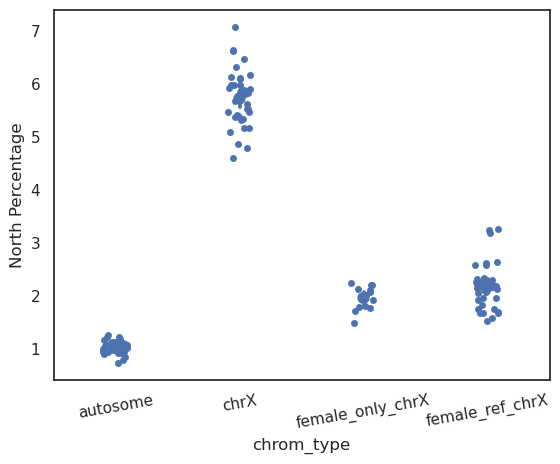

In [7]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Mikumi, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

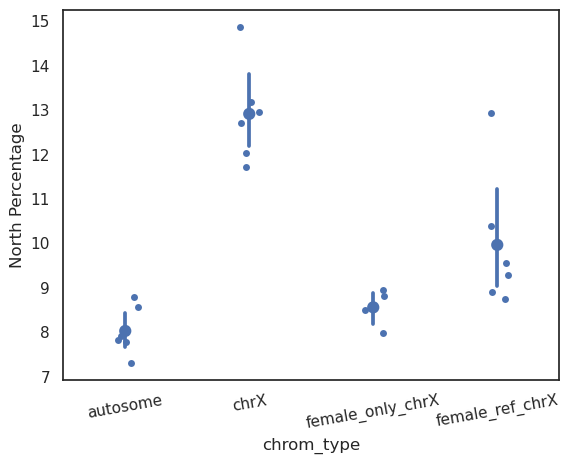

In [8]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Ruaha, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

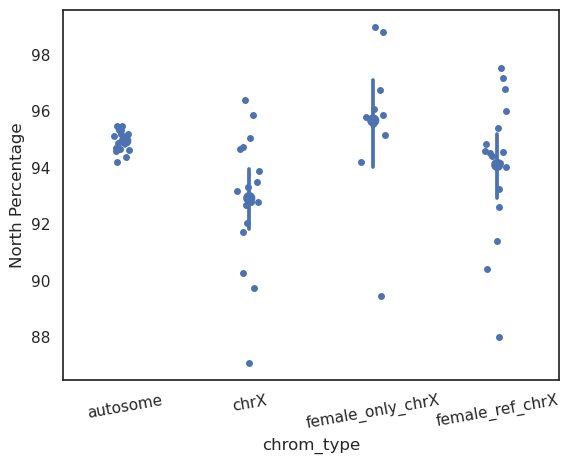

In [9]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Gombe, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

In [10]:
rfmix_path = "../steps/rfmix_gen100/tanzania_close_focus/"

df_l = []
chroms = ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_tanz_close = pd.concat(df_l)
mean_window_df_tanz_close = window_df_tanz_close.groupby(["chrom", "individual", "start", "end"]).mean().reset_index()

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

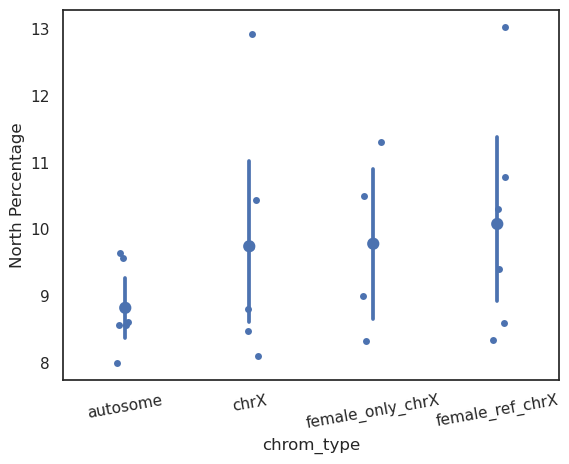

In [11]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Ruaha, Tanzania"].PGDP_ID
window_picked = window_df_tanz_close.loc[window_df_tanz_close.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

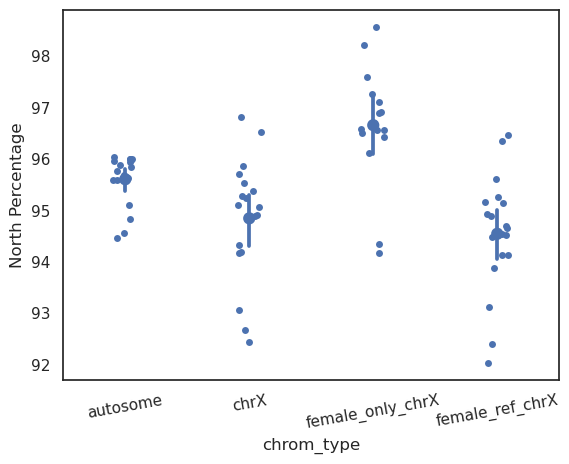

In [19]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Lake Manyara, Tanzania"].PGDP_ID
window_picked = window_df_tanz_close.loc[window_df_tanz_close.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

In [65]:
from scipy import stats
# Distant references
window_df_chrX = window_df_tanz.loc[window_df_tanz["chrom"].isin(["all_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index()
window_df_chrX["chrom"] = "chrX"
window_df_chrX = window_df_chrX.merge(c_r_g_df, on=["chrom", "start"])
window_df_aut = window_df_tanz.loc[~window_df_tanz["chrom"].isin(["all_chrX", "female_chrX", "female_ref_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index().merge(c_r_g_df, on=["chrom", "start"])
# Close references
window_df_chrX_close = window_df_tanz_close.loc[window_df_tanz_close["chrom"].isin(["all_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index()
window_df_chrX_close["chrom"] = "chrX"
window_df_chrX_close = window_df_chrX_close.merge(c_r_g_df, on=["chrom", "start"])
window_df_aut_close = window_df_tanz_close.loc[~window_df_tanz_close["chrom"].isin(["all_chrX", "female_chrX", "female_ref_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index().merge(c_r_g_df, on=["chrom", "start"])

In [81]:
o_l, i_l, admixture_l, admixture_close_l, admixture_chrX_l, admixture_close_chrX_l = [], [], [], [], [], []
aut_corr_l, chrX_corr_l = [], []
for o in ['Arusha, Tanzania',
       'Ngorongoro, Tanzania', 'Ruaha, Tanzania', 'Gombe, Tanzania',
       'Udzungwa, Tanzania', 'Mahale, Tanzania', 'Katavi, Tanzania',
       'Selous, Tanzania', 'Lake Manyara, Tanzania',
       'Tarangire, Tanzania',
       'Issa Valley, Tanzania']:
    print(o)
    ids = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == o].PGDP_ID
    for i in ids:
        ind_window_all = window_df_chrX.loc[(window_df_chrX.individual == i) &
                                           (window_df_chrX.callable_frac > 0.75)]
        ind_window_all_aut = window_df_aut.loc[(window_df_aut.individual == i)&
                                           (window_df_aut.callable_frac > 0.75)]
        ind_window_close = window_df_chrX_close.loc[(window_df_chrX_close.individual == i)&
                                           (window_df_chrX_close.callable_frac > 0.75)]
        ind_window_close_aut = window_df_aut_close.loc[(window_df_aut_close.individual == i)&
                                           (window_df_aut_close.callable_frac > 0.75)]
        if len(ind_window_all_aut) != len(ind_window_close_aut):
            continue
        #print(stats.pearsonr(ind_window_all.north_sum, ind_window_close.north_sum)[0])
        #print(stats.pearsonr(ind_window_all_aut.north_sum, ind_window_close_aut.north_sum)[0])
        o_l.append(o), i_l.append(i)
        admixture_l.append(ind_window_all_aut.north_sum.mean()/1000)
        admixture_close_l.append(ind_window_close_aut.north_sum.mean()/1000)
        admixture_chrX_l.append(ind_window_all.north_sum.mean()/1000)
        admixture_close_chrX_l.append(ind_window_close.north_sum.mean()/1000)
        aut_corr_l.append(stats.pearsonr(ind_window_all_aut.north_sum, ind_window_close_aut.north_sum)[0])
        chrX_corr_l.append(stats.pearsonr(ind_window_all.north_sum, ind_window_close.north_sum)[0])
        #al_l.append()

Arusha, Tanzania
Ngorongoro, Tanzania
Ruaha, Tanzania
Gombe, Tanzania
Udzungwa, Tanzania
Mahale, Tanzania
Katavi, Tanzania
Selous, Tanzania
Lake Manyara, Tanzania
Tarangire, Tanzania
Issa Valley, Tanzania


In [84]:
correlation_df = pd.DataFrame({"Origin": o_l, "Distant autosomal MPA": admixture_l,
              "Close autosomal MPA": admixture_close_l, "Autosomal Correlation": aut_corr_l,
              "Distant ChrX MPA": admixture_chrX_l, "Close ChrX MPA": admixture_close_chrX_l,
              "ChrX Correlation": chrX_corr_l})

In [87]:
correlation_df.groupby(["Origin"]).mean().reset_index()

,Origin,Distant autosomal MPA,Close autosomal MPA,Autosomal Correlation,Distant ChrX MPA,Close ChrX MPA,ChrX Correlation
0,"Arusha, Tanzania",92.7,93.2,0.895,93.8,94,0.795
1,"Gombe, Tanzania",95.1,96.3,0.807,93.7,95.2,0.86
2,"Issa Valley, Tanzania",32.1,35.3,0.931,13.6,17.5,0.708
3,"Katavi, Tanzania",7.73,9.52,0.872,5.09,9.79,0.491
4,"Lake Manyara, Tanzania",95,95.6,0.803,94.9,95.6,0.76
5,"Mahale, Tanzania",10.3,12.7,0.875,4.74,10.3,0.451
6,"Ngorongoro, Tanzania",94.8,95.7,0.81,95.8,96,0.694
7,"Ruaha, Tanzania",8.02,8.83,0.889,12.9,9.69,0.698
8,"Tarangire, Tanzania",79.1,79.4,0.946,75,74.2,0.915
9,"Udzungwa, Tanzania",1.42,1.37,0.791,6.39,2.04,0.486


In [16]:
ind_window_female_ref

,chrom,individual,haplotype,start,end,north_sum
186810,female_ref_chrX,PD_0503,0,0,100000,0
186811,female_ref_chrX,PD_0503,0,100000,200000,0
186812,female_ref_chrX,PD_0503,0,200000,300000,0
186813,female_ref_chrX,PD_0503,0,300000,400000,0
186814,female_ref_chrX,PD_0503,0,400000,500000,0
...,...,...,...,...,...,...
189679,female_ref_chrX,PD_0503,1,143200000,143300000,0
189680,female_ref_chrX,PD_0503,1,143300000,143400000,0
189681,female_ref_chrX,PD_0503,1,143400000,143500000,0
189682,female_ref_chrX,PD_0503,1,143500000,143600000,0
